## Survival Analysis: Time Until a ≥5% Daily Increase

In this section, I reframe stock prediction as a survival analysis problem.  
Instead of predicting the exact next-day return, I model the **time until the next ≥5% daily increase** in stock price.

This is useful because in financial markets it is often important not only to know **whether** a strong move may happen, but also **how soon** it may happen.  
I use one pooled survival model across all stocks, then evaluate performance for each stock separately.

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.utils import concordance_index

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [44]:
data_path = Path("../01_data/raw/df_eda.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (19836, 17)


,Date,Open,High,Low,Close,Adj Close,Volume,Ticker,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Target_Return_1d,Weekday,Month
0,2010-01-04,7.622500,7.660714,7.585000,7.643214,6.412384,493729600,AAPL,NaN,NaN,NaN,NaN,NaN,NaN,0.001729,Monday,January
1,2010-01-05,7.664286,7.699643,7.616071,7.656429,6.423470,601904800,AAPL,0.001729,NaN,NaN,NaN,NaN,0.219098,-0.015906,Tuesday,January
2,2010-01-06,7.656429,7.686786,7.526786,7.534643,6.321297,552160000,AAPL,-0.015906,NaN,NaN,NaN,NaN,-0.082646,-0.001849,Wednesday,January
3,2010-01-07,7.562500,7.571429,7.466071,7.520714,6.309608,477131200,AAPL,-0.001849,-0.016028,NaN,NaN,NaN,-0.135882,0.006648,Thursday,January
4,2010-01-08,7.510714,7.571429,7.466429,7.570714,6.351556,447610800,AAPL,0.006648,-0.011195,NaN,NaN,NaN,-0.061871,-0.008821,Friday,January


### Prepare the dataset

The dataset already contains lagged return, volatility, and volume-based features, so I use them directly.  
I also create log-transformed volume to reduce scale effects.

To avoid data leakage, I split the data by date first and then create survival targets separately for train and test periods.

In [45]:
df_surv = df.copy()

df_surv["Date"] = pd.to_datetime(df_surv["Date"])
df_surv = df_surv.sort_values(["Ticker", "Date"]).reset_index(drop=True)

df_surv["Log_Volume"] = np.log1p(df_surv["Volume"])

numeric_features = [
    "Return_1d",
    "Return_3d",
    "Return_5d",
    "Volatility_5d",
    "Volatility_20d",
    "Volume_Change_1d",
    "Log_Volume"
]

categorical_features = ["Ticker", "Weekday", "Month"]

base_cols = ["Date", "Target_Return_1d"] + numeric_features + categorical_features
df_surv = df_surv[base_cols].copy()

df_surv = df_surv.dropna(subset=numeric_features + ["Target_Return_1d"]).reset_index(drop=True)

df_surv.head()

,Date,Target_Return_1d,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Ticker,Weekday,Month
0,2010-02-02,0.017206,0.005803,-0.017211,-0.048946,0.026783,0.022815,-0.068723,20.364220,AAPL,Tuesday,February
1,2010-02-03,-0.036039,0.017206,0.037332,-0.041610,0.028353,0.023283,-0.118873,20.237666,AAPL,Wednesday,February
2,2010-02-04,0.017756,-0.036039,-0.013762,-0.036329,0.026866,0.024267,0.231298,20.445735,AAPL,Thursday,February
3,2010-02-05,-0.006856,0.017756,-0.002042,0.017703,0.022736,0.024767,0.122292,20.561108,AAPL,Friday,February
4,2010-02-08,0.010663,-0.006856,-0.025649,-0.003132,0.022304,0.024661,-0.437531,19.985688,AAPL,Monday,February


### Split data chronologically

I use a time-based split so that the model is trained on earlier observations and evaluated on later ones.  
This better reflects a realistic forecasting setup.

In [46]:
unique_dates = np.sort(df_surv["Date"].unique())
split_idx = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_idx]

train_raw = df_surv[df_surv["Date"] < split_date].copy()
test_raw = df_surv[df_surv["Date"] >= split_date].copy()

print("Split date:", pd.to_datetime(split_date).date())
print("Train shape:", train_raw.shape)
print("Test shape:", test_raw.shape)

Split date: 2023-01-03
Train shape: (15661, 12)
Test shape: (4070, 12)


### Create survival target

The event is defined as a **next-day return of at least 5%**.

For each row, I calculate:

- **Event_Next_5pct**: whether the next day already reaches the 5% threshold
- **Duration**: number of trading days until the next such event
- **Observed**: whether the event is observed in the available period or censored

Rows with no future 5% event within the given time window are treated as **right-censored**.  
This means the event is not seen in the available data window, even though it could still occur later.  
In other words, survival analysis uses right-censoring to capture **unfinished waiting times** rather than assuming the event never happens.

In [57]:
def build_survival_dataset(data, threshold=0.05):
    """
    Create survival targets for each ticker and keep the Ticker column.

    Computes whether a 5% next-day return event occurs, how many trading days
    remain until that event, and whether the event is observed or right-censored.
    """
    def per_ticker(group):
        ticker = group.name
        g = group.sort_values("Date").copy()
        g["Ticker"] = ticker

        event_now = (g["Target_Return_1d"] >= threshold).astype(int).to_numpy()
        n = len(g)

        durations = np.zeros(n, dtype=int)
        observed = np.zeros(n, dtype=int)

        next_event_idx = None

        for i in range(n - 1, -1, -1):
            if event_now[i] == 1:
                next_event_idx = i
                durations[i] = 1
                observed[i] = 1
            else:
                if next_event_idx is None:
                    durations[i] = n - i
                    observed[i] = 0
                else:
                    durations[i] = next_event_idx - i + 1
                    observed[i] = 1

        g["Event_Next_5pct"] = event_now
        g["Duration"] = durations
        g["Observed"] = observed

        return g

    return (
        data.groupby("Ticker", group_keys=False)
        .apply(per_ticker, include_groups=False)
        .reset_index(drop=True)
    )

full_surv = build_survival_dataset(df_surv)
train_surv = build_survival_dataset(train_raw)
test_surv = build_survival_dataset(test_raw)

full_surv.head()

,Date,Target_Return_1d,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Weekday,Month,Ticker,Event_Next_5pct,Duration,Observed
0,2010-02-02,0.017206,0.005803,-0.017211,-0.048946,0.026783,0.022815,-0.068723,20.364220,Tuesday,February,AAPL,0,54,1
1,2010-02-03,-0.036039,0.017206,0.037332,-0.041610,0.028353,0.023283,-0.118873,20.237666,Wednesday,February,AAPL,0,53,1
2,2010-02-04,0.017756,-0.036039,-0.013762,-0.036329,0.026866,0.024267,0.231298,20.445735,Thursday,February,AAPL,0,52,1
3,2010-02-05,-0.006856,0.017756,-0.002042,0.017703,0.022736,0.024767,0.122292,20.561108,Friday,February,AAPL,0,51,1
4,2010-02-08,0.010663,-0.006856,-0.025649,-0.003132,0.022304,0.024661,-0.437531,19.985688,Monday,February,AAPL,0,50,1


,Date,Target_Return_1d,Duration,Observed
0,2010-02-26,0.051858,1,1
1,2010-03-24,0.052249,1,1
2,2010-04-20,0.059815,1,1
3,2010-05-07,0.076867,1,1
4,2010-05-07,0.050488,1,1
...,...,...,...,...
237,2025-11-21,0.063138,1,1
238,2026-01-21,0.056562,1,1
239,2026-01-28,0.104048,1,1
240,2026-03-30,0.066651,1,1


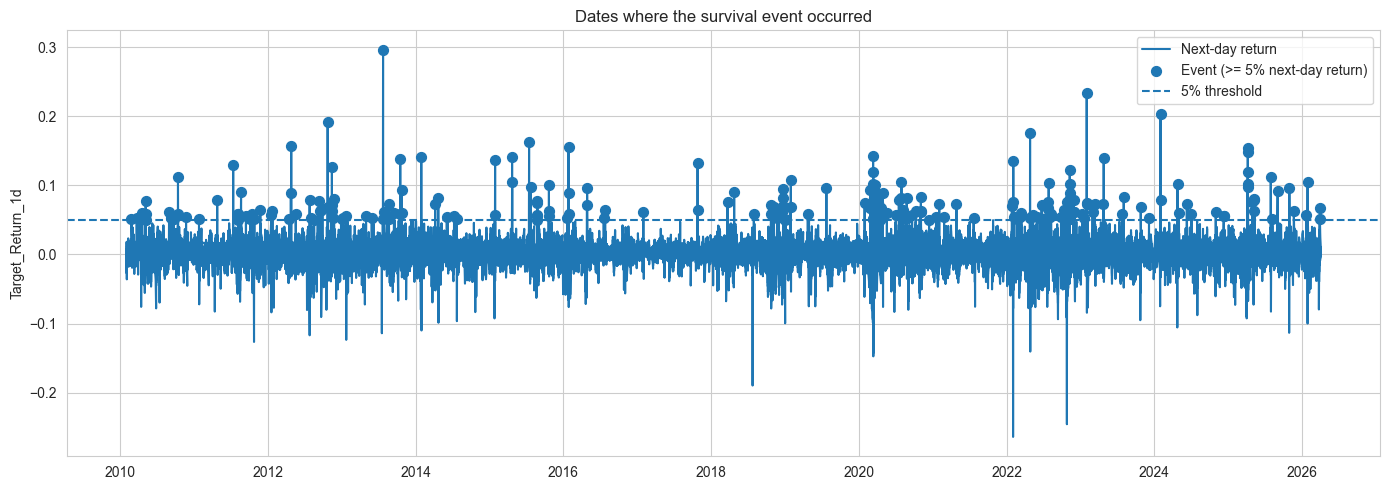

In [48]:
event_df = full_surv.copy()

event_df["Date"] = pd.to_datetime(event_df["Date"])

events_only = event_df[event_df["Event_Next_5pct"] == 1].copy()

display(
    events_only[["Date", "Target_Return_1d", "Duration", "Observed"]]
    .sort_values("Date")
    .reset_index(drop=True)
)

plt.figure(figsize=(14, 5))
plt.plot(event_df["Date"], event_df["Target_Return_1d"], label="Next-day return")
plt.scatter(
    events_only["Date"],
    events_only["Target_Return_1d"],
    s=50,
    label="Event (>= 5% next-day return)"
)

plt.axhline(0.05, linestyle="--", label="5% threshold")
plt.title("Dates where the survival event occurred")
plt.xlabel("")
plt.ylabel("Target_Return_1d")
plt.legend()
plt.tight_layout()
plt.show()

The plot shows that **5% next-day return events are relatively rare** compared with normal daily movements.  
In total, there are **242 observed event rows** where occurred **≥5%** events.
Since only event rows are displayed here, their **Duration = 1** and **Observed = 1**, meaning the threshold\
is reached immediately on the next trading day.

### Check event frequency and censoring

Before fitting the model, I inspect how often the event happens and how much censoring is present.  
This is important because a 5% next-day increase is relatively rare for large-cap stocks.

In [49]:
event_summary = (
    full_surv.groupby("Ticker").agg(
        Rows=("Ticker", "size"),
        Event_Rate=("Event_Next_5pct", "mean"),
        Observed_Rate=("Observed", "mean"),
        Median_Duration=("Duration", "median")
    )
    .reset_index()
)

event_summary

,Ticker,Rows,Event_Rate,Observed_Rate,Median_Duration
0,AAPL,4066,0.009592,0.959420,82.0
1,AMZN,4066,0.015248,0.974422,50.0
2,GOOGL,4066,0.009100,0.999508,85.0
3,META,3467,0.021633,0.999423,50.0
4,MSFT,4066,0.007132,0.943187,113.0


The event is rare for all stocks, with event rates below **3%**.  
**META** and **AMZN** show the highest event frequency and shorter median waiting times,\
while **MSFT** has the lowest event rate and the longest median duration.  
Observed rates are high across all stocks, meaning most rows eventually reach the event within the available sample.

### Kaplan-Meier curves

As a descriptive baseline, I plot Kaplan-Meier survival curves for each stock.  
These curves show the probability that a **5% next-day increase has not yet occurred**\
after a given number of trading days.  

We need this step to get a simple, model-free view of **how quickly the event tends to happen**\
and to compare survival patterns across stocks before fitting survival models.

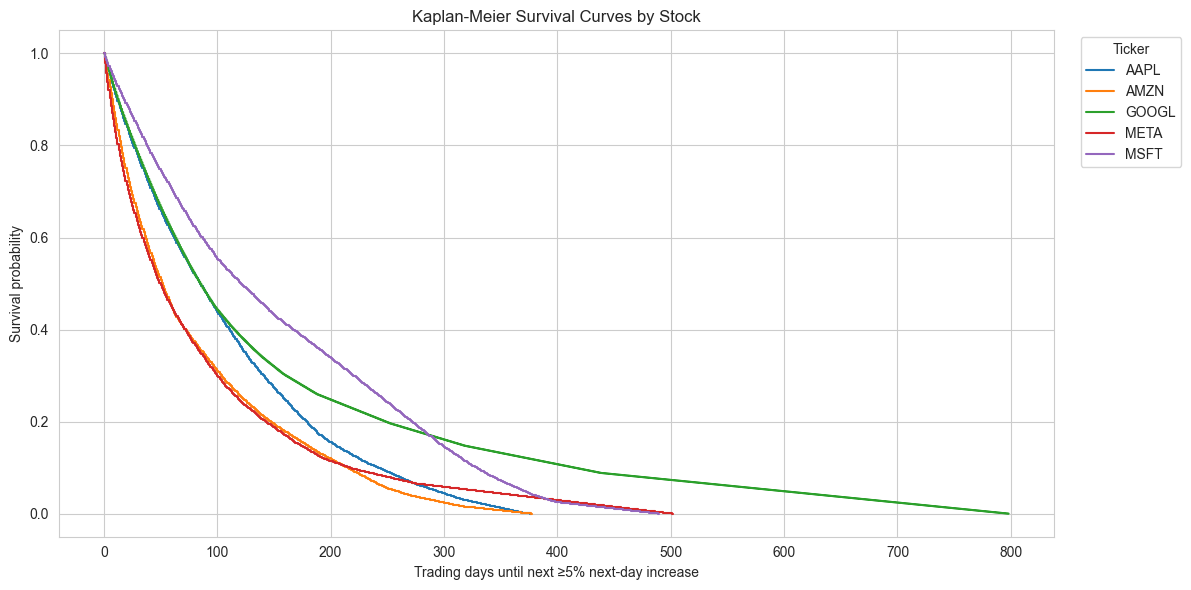

In [50]:
kmf = KaplanMeierFitter()

plt.figure(figsize=(12, 6))

for ticker, temp in full_surv.groupby("Ticker"):
    kmf.fit(
        durations=temp["Duration"],
        event_observed=temp["Observed"],
        label=ticker
    )
    kmf.plot_survival_function(ci_show=False)

plt.title("Kaplan-Meier Survival Curves by Stock")
plt.xlabel("Trading days until next ≥5% next-day increase")
plt.ylabel("Survival probability")
plt.legend(title="Ticker", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

The lines go down as time passes, which means the chance of **not seeing** a **5%**\
next-day gain becomes smaller over time.  
**AMZN** and **META** fall faster, so this event tends to happen sooner for them.  
**GOOGL** and **MSFT** fall more slowly, which suggests longer waiting times until the event.

### Prepare data for the Cox proportional hazards model

I use a pooled Cox proportional hazards model as a baseline survival model.  
It estimates how the features affect the **hazard**, meaning the chance that the\
event happens sooner rather than later.

Ticker, weekday, and month are included as categorical variables, so the model\
remains shared across all stocks while still accounting for differences between them.  

We need this step to build a **single interpretable survival model** that can show\
which factors are linked to faster or slower time until a **5%** next-day gain.

In [51]:
model_features = numeric_features + categorical_features

X_train = pd.get_dummies(
    train_surv[model_features],
    columns=categorical_features,
    drop_first=True
)

X_test = pd.get_dummies(
    test_surv[model_features],
    columns=categorical_features,
    drop_first=True
)

# Align columns
X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

# Scale numeric columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

cox_train = pd.concat(
    [X_train.reset_index(drop=True),
     train_surv[["Duration", "Observed"]].reset_index(drop=True)],
    axis=1
)

cox_test = pd.concat(
    [X_test.reset_index(drop=True),
     test_surv[["Duration", "Observed"]].reset_index(drop=True)],
    axis=1
)

cox_train.head()

,Return_1d,Return_3d,Return_5d,Volatility_5d,Volatility_20d,Volume_Change_1d,Log_Volume,Ticker_AMZN,Ticker_GOOGL,Ticker_META,Ticker_MSFT,Weekday_Monday,Weekday_Thursday,Weekday_Tuesday,Weekday_Wednesday,Month_August,Month_December,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Duration,Observed
0,0.250882,-0.607488,-1.278056,0.945179,0.604491,-0.314869,2.699478,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,54,1
1,0.836581,1.054892,-1.102672,1.084639,0.657469,-0.436010,2.561649,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,53,1
2,-1.898256,-0.502375,-0.976396,0.952568,0.768723,0.409848,2.788255,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,52,1
3,0.864801,-0.145172,0.315398,0.585542,0.825220,0.146539,2.913907,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,51,1
4,-0.399319,-0.864657,-0.182733,0.547189,0.813318,-1.205746,2.287222,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,50,1


This table shows the final training data used for the Cox proportional hazards model.  
Numeric variables were standardized, while ticker, weekday, and month were converted into dummy variables.  
Because `drop_first=True` was used, one category from each categorical feature is left out and becomes\
the **reference group**. For example, **Friday** is the baseline weekday, so the other weekday columns\
are interpreted relative to Friday.  

The target columns **Duration** and **Observed** were then added, so the dataset is ready for survival modeling.

### Fit the Cox model

Positive coefficients indicate a higher hazard, meaning the 5% increase is expected to happen sooner.  
Negative coefficients indicate a lower hazard, meaning the event is expected to take longer.

In [59]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_train, duration_col="Duration", event_col="Observed")

cph.summary[["coef", "exp(coef)", "p"]].sort_values("coef", ascending=False).head(15)

,coef,exp(coef),p
covariate,,,
Volatility_20d,0.345444,1.412617,6.038467e-238
Month_July,0.148741,1.160372,4.399681e-06
Ticker_AMZN,0.136717,1.146504,8.145334e-09
Month_September,0.111643,1.118114,6.559998e-04
Ticker_META,0.093037,1.097503,2.840407e-03
Month_October,0.091637,1.095966,4.240757e-03
Log_Volume,0.057452,1.059135,1.039081e-07
Volatility_5d,0.051280,1.052618,7.194310e-08
Month_June,0.029897,1.030348,3.546057e-01


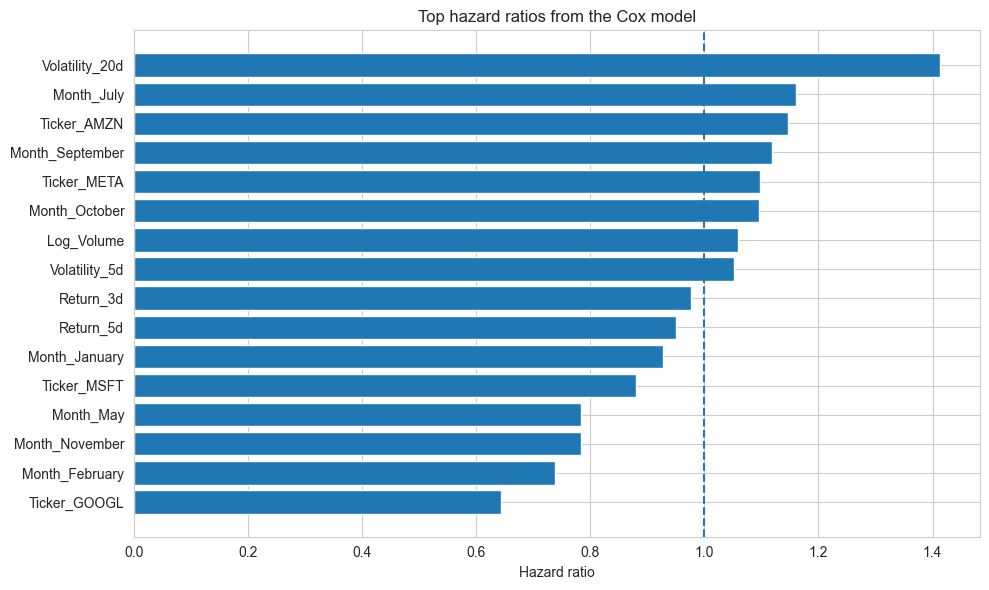

In [60]:
cox_summary = cph.summary.reset_index()[["covariate", "coef", "exp(coef)", "p"]]

top_pos = cox_summary.sort_values("exp(coef)", ascending=False).head(8)
top_neg = cox_summary.sort_values("exp(coef)", ascending=True).head(8)

plot_df = pd.concat([top_neg, top_pos]).drop_duplicates().sort_values("exp(coef)")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["covariate"], plot_df["exp(coef)"])
plt.axvline(1, linestyle="--")
plt.title("Top hazard ratios from the Cox model")
plt.xlabel("Hazard ratio")
plt.ylabel("")
plt.tight_layout()
plt.show()

With a **0.1 penalty**, the Cox model remains regularized but still keeps the main signals visible.  
The strongest effect comes from **20-day volatility**, which has the highest hazard ratio, suggesting\
that more volatile stocks tend to reach a **5%** next-day gain sooner what makes totally sense.\
**AMZN** and **META** also show a higher hazard than the baseline stock, while July, September,\
and October are associated with slightly faster event timing.  
Most weekday effects and several month effects are small and not statistically meaningful,\
so volatility appears to be the main driver in this model.

### Evaluate the model

I evaluate the survival model using the **concordance index (C-index)**.  
This tells us how well the model can **rank rows by which one is more likely to reach the event sooner**.

We need this metric because survival analysis focuses on **event timing**, not just whether the event happens.  
A higher C-index means the model is better at identifying which observations are likely to experience the 5% next-day gain earlier.

In [ ]:
test_eval = test_surv.reset_index(drop=True).copy()

test_eval["Risk_Score"] = cph.predict_partial_hazard(X_test).values.flatten()

overall_cindex = concordance_index(
    event_times=test_eval["Duration"],
    predicted_scores=-test_eval["Risk_Score"],
    event_observed=test_eval["Observed"]
)

print(f"Overall test C-index: {overall_cindex:.4f}")

Overall test C-index: 0.5483


The overall test **C-index is 0.5483**, which is only slightly better than random ranking.  
This means the model captures some signal about which rows are likely to reach the event\
sooner, but its predictive power is fairly weak. 

In [62]:
def safe_cindex(group):
    """Return C-index for one stock group, or NaN if it cannot be computed."""
    try:
        return concordance_index(
            event_times=group["Duration"],
            predicted_scores=-group["Risk_Score"],
            event_observed=group["Observed"]
        )
    except Exception:
        return np.nan

stock_results = (
    test_eval.groupby("Ticker")[["Duration", "Risk_Score", "Observed", "Event_Next_5pct"]]
    .apply(lambda g: pd.Series({
        "Rows": len(g),
        "Event_Rate": g["Event_Next_5pct"].mean(),
        "Observed_Rate": g["Observed"].mean(),
        "Median_Actual_Duration": g["Duration"].median(),
        "C_Index": safe_cindex(g)
    }))
    .reset_index()
    .sort_values("C_Index", ascending=False)
)

stock_results

,Ticker,Rows,Event_Rate,Observed_Rate,Median_Actual_Duration,C_Index
4,MSFT,814.0,0.003686,0.716216,157.5,0.597221
1,AMZN,814.0,0.011057,0.872236,52.5,0.588280
0,AAPL,814.0,0.006143,0.797297,100.5,0.514529
3,META,814.0,0.014742,0.997543,52.0,0.467632
2,GOOGL,814.0,0.013514,0.997543,48.0,0.427258


The model works best for **MSFT** and **AMZN**, where the C-index is above 0.5.  
It is close to random for **AAPL** and weaker for **META** and **GOOGL**.  
This suggests the pooled Cox model captures some signal, but results are inconsistent across stocks.

### Visualize survival model performance by stock

To make the results easier to compare, I visualize the C-index for each stock separately.

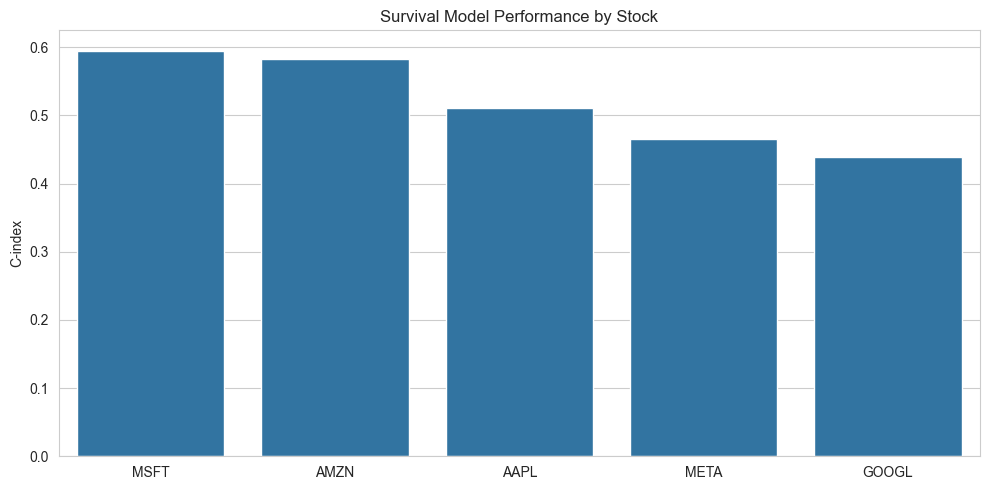

In [55]:
plt.figure(figsize=(10, 5))
sns.barplot(data=stock_results, x="Ticker", y="C_Index")
plt.title("Survival Model Performance by Stock")
plt.xlabel("")
plt.ylabel("C-index")
plt.tight_layout()
plt.show()

### Survival analysis conclusions

Survival analysis helps model **when** a large positive move may happen, not just whether it happens.  
The Kaplan-Meier curves show the general waiting-time patterns for each stock, while the Cox model\
estimates how the features relate to faster or slower event timing.

Since a **5% next-day gain is rare**, this is a hard task.  
Because of that, the survival model is more useful as a **baseline ranking tool for event timing** than as a highly accurate predictor.